# Array Processing Project 2: Speech Enhancement

In [60]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile, loadmat
from scipy.signal import spectrogram
from utils import *

## Inspecting the data

In [61]:
# Folder with the data files
DATA = "Data/"  

wav_files = {
    "clean_speech":   "clean_speech.wav",
    "clean_speech_2": "clean_speech_2.wav",
    "babble":         "babble_noise.wav",
    "nonstat":        "aritificial_nonstat_noise.wav",  
    "ssn":            "Speech_shaped_noise.wav",
}

signals = {}
for name, fname in wav_files.items():
    fs, x = wavfile.read(f"{DATA}/{fname}")
    signals[name] = x
    print(f"{name:15s} fs={fs:6d}  shape={x.shape}  dtype={x.dtype}  "
          f"dur={x.shape[0]/fs:.2f}s")

# Load impulse responses 
mat = loadmat(f"{DATA}/impulse_responses.mat")
print("\n.mat keys:", [k for k in mat.keys() if not k.startswith("__")])
for k in mat:
    if not k.startswith("__"):
        print(f"  {k}: shape={np.array(mat[k]).shape}, dtype={np.array(mat[k]).dtype}")

clean_speech    fs= 16000  shape=(577655,)  dtype=int16  dur=36.10s
clean_speech_2  fs= 16000  shape=(537706,)  dtype=int16  dur=33.61s
babble          fs= 16000  shape=(600001,)  dtype=int16  dur=37.50s
nonstat         fs= 16000  shape=(577655,)  dtype=int16  dur=36.10s
ssn             fs= 16000  shape=(1440000,)  dtype=int16  dur=90.00s

.mat keys: ['h_inter1', 'h_inter2', 'h_inter3', 'h_inter4', 'h_target']
  h_inter1: shape=(4, 400), dtype=float64
  h_inter2: shape=(4, 400), dtype=float64
  h_inter3: shape=(4, 400), dtype=float64
  h_inter4: shape=(4, 400), dtype=float64
  h_target: shape=(4, 400), dtype=float64


### Look at the RIRs

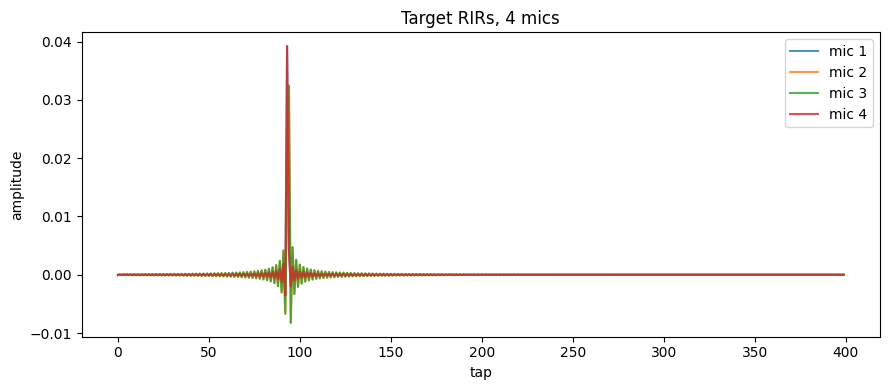

peak tap per mic: [93 94 94 93] , spread of 1 samples


In [62]:
# Extract impulse responses from the .mat file
h_target = mat["h_target"]      
h_1 = mat["h_inter1"]           
h_2 = mat["h_inter2"]         
h_3 = mat["h_inter3"]        
h_4 = mat["h_inter4"]         

# Plot the target RIRs
n_mics = h_target.shape[0]
n_taps = h_target.shape[1]

fig, ax = plt.subplots(figsize=(9, 4))
for m in range(n_mics):
    ax.plot(np.arange(n_taps), h_target[m], label=f"mic {m+1}", alpha=0.8)
ax.set_xlabel("tap"); ax.set_ylabel("amplitude")
ax.set_title("Target RIRs, 4 mics")
ax.legend()
plt.tight_layout()
plt.show()

# Look at where the peaks of the target RIRs are
peaks = np.argmax(np.abs(h_target), axis=1)
print("peak tap per mic:", peaks, ", spread of", peaks.max()-peaks.min(), "samples")

In [63]:
# Look at the correlation between the impulse responses of the target source since the peaks are very close to each other, we expect the RIRs to be very similar across mics
for m in range(1, n_mics):
    c = np.corrcoef(h_target[0], h_target[m])[0, 1]
    print(f"h_target: corr(mic1, mic{m+1}) = {c:.3f}")

# Look at the correlation between the impulse responses of the interfering sources
for name, h in [("h_1", h_1), ("h_2", h_2), ("h_3", h_3), ("h_4", h_4)]:
    c14 = np.corrcoef(h[0], h[3])[0, 1]
    c23= np.corrcoef(h[1], h[2])[0, 1]
    print(f"{name}: corr(mic1, mic4) = {c14:.3f}")
    print(f"{name}: corr(mic2, mic3) = {c23:.3f}")

h_target: corr(mic1, mic2) = 0.558
h_target: corr(mic1, mic3) = 0.558
h_target: corr(mic1, mic4) = 1.000
h_1: corr(mic1, mic4) = -0.014
h_1: corr(mic2, mic3) = -0.014
h_2: corr(mic1, mic4) = -0.020
h_2: corr(mic2, mic3) = -0.019
h_3: corr(mic1, mic4) = -0.010
h_3: corr(mic2, mic3) = -0.018
h_4: corr(mic1, mic4) = -0.014
h_4: corr(mic2, mic3) = -0.014


### Look at the signals

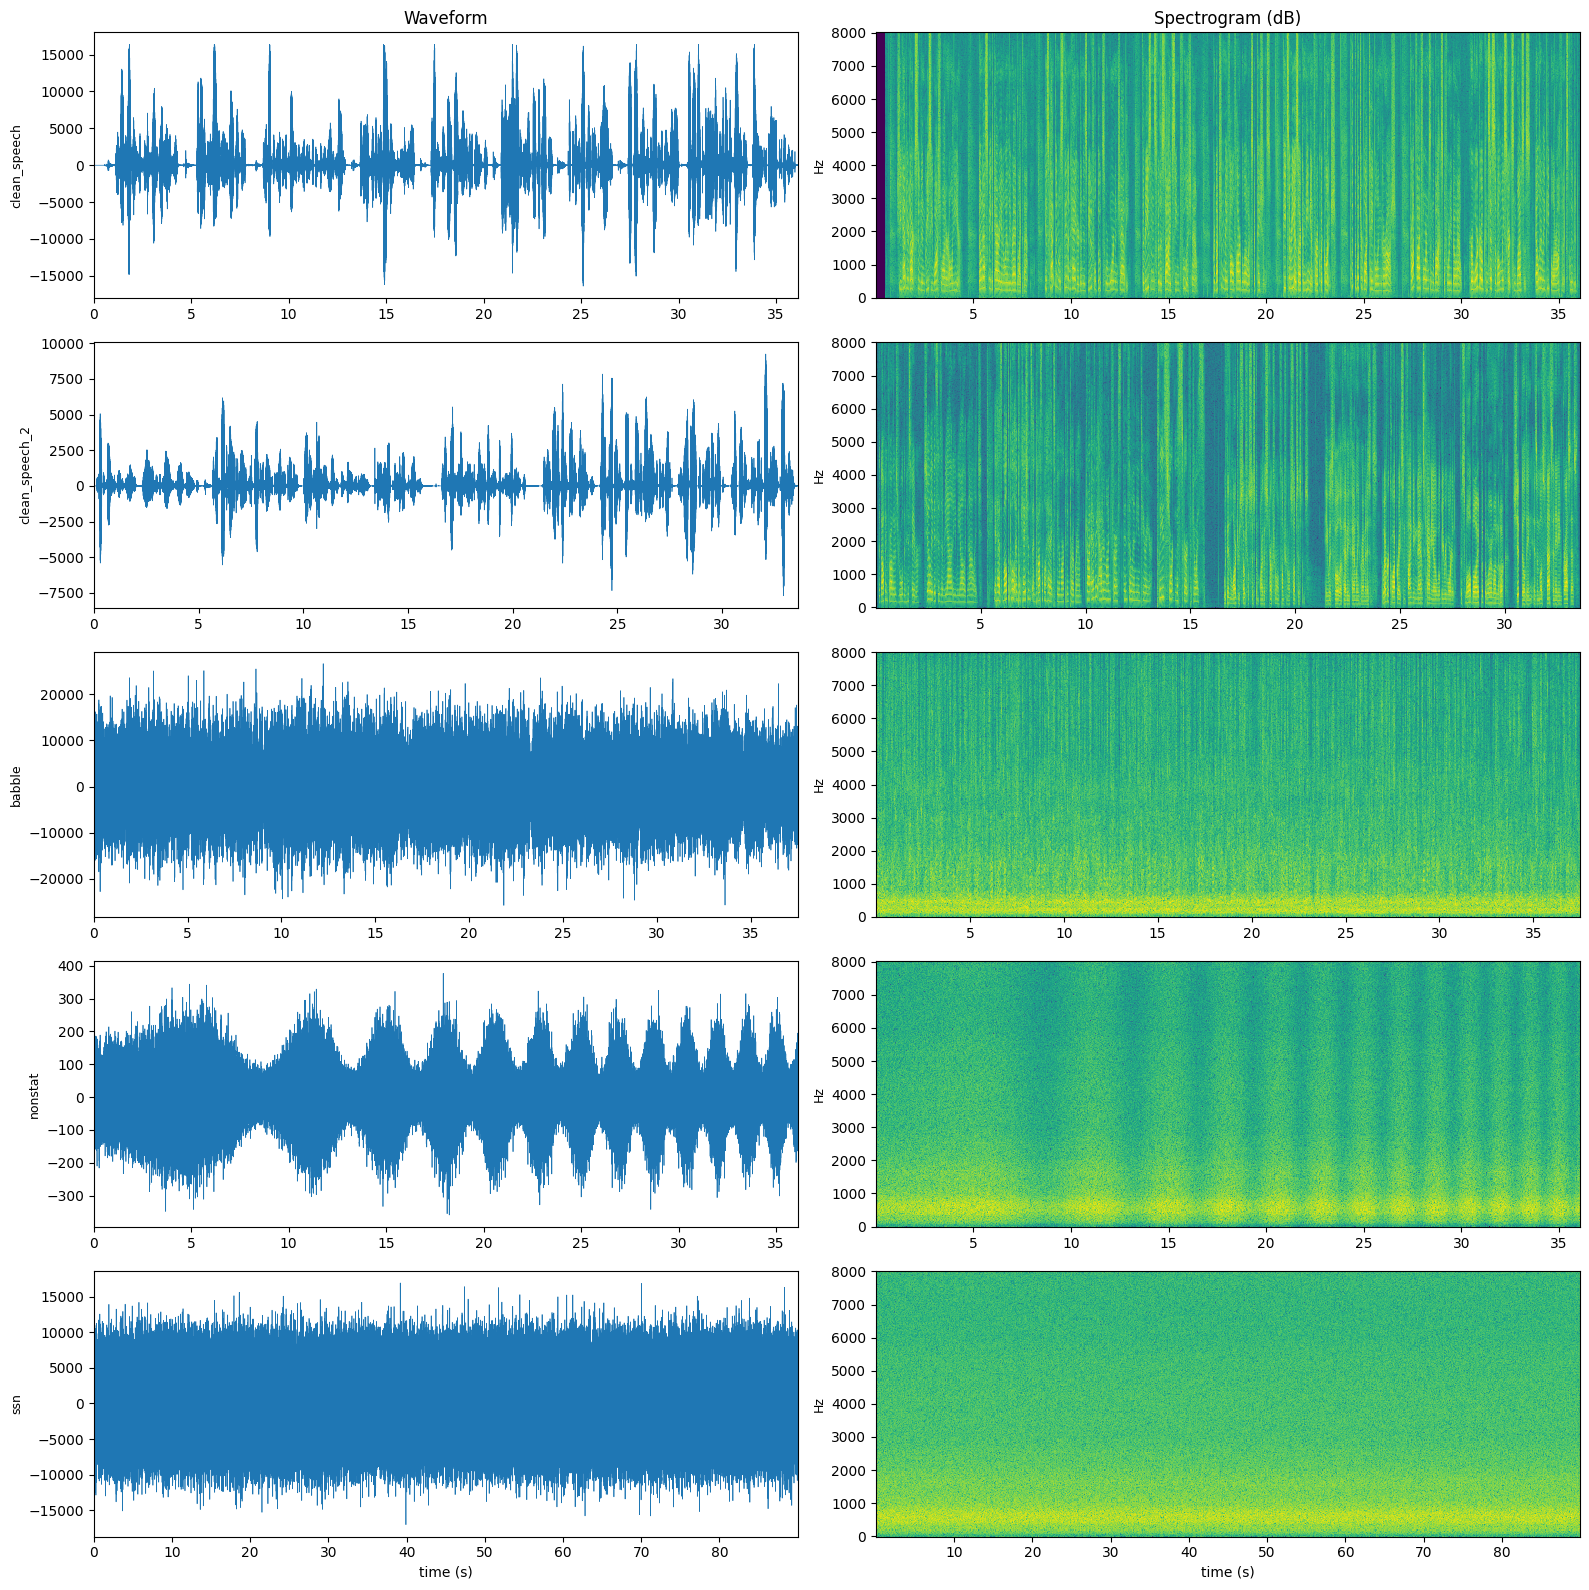

In [64]:
# Plot the waveforms and spectrograms of the signals
fs = 16000

# Convert signals to float64 for better plotting and spectrograms
signals = {k: v.astype(np.float64) for k, v in signals.items()}
order = ["clean_speech", "clean_speech_2", "babble", "nonstat", "ssn"]

# Plot waveforms and spectrograms
fig, axes = plt.subplots(len(order), 2, figsize=(16, 16))
for row, name in enumerate(order):
    x = signals[name]
    t = np.arange(len(x)) / fs

    # time domain
    axes[row, 0].plot(t, x, lw=0.5)
    axes[row, 0].set_ylabel(name, fontsize=9)
    axes[row, 0].set_xlim(0, t[-1])
    if row == 0:
        axes[row, 0].set_title("Waveform")

    # spectrogram
    f, tt, Sxx = spectrogram(x, fs, nperseg=512, noverlap=256)
    axes[row, 1].pcolormesh(tt, f, 10*np.log10(Sxx + 1e-12), shading="auto")
    axes[row, 1].set_ylabel("Hz", fontsize=9)
    if row == 0:
        axes[row, 1].set_title("Spectrogram (dB)")

axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## Create signal model

In [65]:
# Build a mixture with the target and all 4 interferers, at 0 dB SNR at the reference mic
h_inters = [h_1, h_2, h_3, h_4]
interferers = [signals["clean_speech_2"],
               signals["babble"],
               signals["nonstat"],
               signals["ssn"]]

scene = make_mixture(
    target_sig=signals["clean_speech"],
    interferer_sigs=interferers,
    h_target=h_target,
    h_inters=h_inters,
    snr_db=0.0,  # acoustic input SNR
    sensor_snr_db=40.0,  
)

# Check that the snr at the reference mic is indeed 0 dB
P_t = np.mean(scene["target_image"][0]**2)
P_n = np.mean(scene["noise_image"][0]**2)
print(f"measured input SNR at ref mic: {10*np.log10(P_t/P_n):.2f} dB")
print("mix shape:", scene["mix"].shape)

measured input SNR at ref mic: -0.00 dB
mix shape: (4, 537706)


## Go to frequency domain with STFT

In [66]:
# Compute the STFT of the mixture
NPERSEG = 512
signal = scene["mix"]
f, t, X_mix = multichannel_stft(scene["mix"], nperseg=NPERSEG)
print("STFT shape (mics, freq, frames):", X_mix.shape)
print(f"{len(f)} freq bins, {len(t)} frames")

# Check if the inverse STFT recovers the original mixture
signal_recovered = multichannel_istft(X_mix, nperseg=NPERSEG)
N = min(signal.shape[1], signal_recovered.shape[1])
err = np.max(np.abs(signal[:, :N] - signal_recovered[:, :N]))
print(f"max reconstruction error: {err:.2e}")

STFT shape (mics, freq, frames): (4, 257, 2102)
257 freq bins, 2102 frames
max reconstruction error: 3.41e-13


## Estimate Rn and ATF

In [67]:
# STFT the ground-truth components 
_, _, X_tgt = multichannel_stft(scene["target_image"], nperseg=NPERSEG)
_, _, X_noise = multichannel_stft(scene["noise_image"], nperseg=NPERSEG)

# Ground truth covariances
R_x_truth = spatial_covariance(X_mix)
R_s_truth = spatial_covariance(X_tgt) 
R_n_truth = spatial_covariance(X_noise) 

print("covariance shapes:", R_n_truth.shape)  

# Check that the covariance of the mixture is approximately the sum of the covariances of the target and noise
err = np.max(np.abs(R_x_truth - (R_s_truth + R_n_truth)))
scale = np.max(np.abs(R_x_truth))
print(f"Sigma_x vs Sigma_s + Sigma_u mismatch: {err:.3e}")
print(f"max |Sigma_x| entry: {scale:.3e}")
print(f"relative mismatch:   {err/scale:.3e}")

covariance shapes: (257, 4, 4)
Sigma_x vs Sigma_s + Sigma_u mismatch: 1.016e+01
max |Sigma_x| entry: 3.946e+02
relative mismatch:   2.574e-02


In [68]:
# Check the speech presence detector
present, truth = speech_presence_detector(X_mix, X_tgt)
tp = np.sum(present & truth)
fp = np.sum(present & ~truth)
fn = np.sum(~present & truth)
tn = np.sum(~present & ~truth)
print(f"detector vs oracle:  TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"  noise-only frames detector found: {tn}/{tn+fp} "
      f"({100*tn/max(tn+fp,1):.0f}% of true noise frames)")

detector vs oracle:  TP=38415 FP=23848 FN=26984 TN=450967
  noise-only frames detector found: 450967/474815 (95% of true noise frames)


In [69]:
# Estimate the covariances using the speech presence detector
R_x_est, R_n_est = estimate_covariances_perbin(X_mix, present)

# energy-weighted overall error
num = np.linalg.norm((R_n_est - R_n_truth).reshape(257,-1), axis=1)
den = np.linalg.norm(R_n_truth.reshape(257,-1), axis=1)
w = den/den.sum()
print(f"energy-weighted Sigma_u rel err: {np.sum(w*num/np.maximum(den,1e-12)):.3f}")

energy-weighted Sigma_u rel err: 0.242


In [70]:
# Check the RTF of the target source using the ground-truth covariance
rtf_truth = rtf_from_covariance(R_s_truth)
print("RTF shape:", rtf_truth.shape)
print("ref-mic entries (should be 1):", np.allclose(rtf_truth[:, 0], 1.0))

# Estimate the RTF from the estimated covariances
rtf_cw = rtf_covariance_whitening(R_x_est, R_n_est)

# Check how well the estimated RTF matches the oracle RTF, using the cosine similarity
cos_sim = rtf_match(rtf_cw, rtf_truth)
print('RTF match cosine similarity')
print(f"mean: {cos_sim.mean():.3f}")
print(f"median: {np.median(cos_sim):.3f}")
print(f"min: {cos_sim.min():.3f}")

RTF shape: (257, 4)
ref-mic entries (should be 1): True
RTF match cosine similarity
mean: 0.973
median: 0.999
min: 0.234


## Create the Beamformers

In [71]:
# Beamformers using ground-truth rtf and Rn
w_ds_tr = bf_delay_and_sum(rtf_truth)
w_mvdr_tr = bf_mvdr(rtf_truth, R_n_truth)
w_mwf_tr = bf_sdw_mwf(rtf_truth, R_n_truth, R_s_scalar=R_s_truth, mu=1.0)

# Beamformers using estimated rtf, Rx and Rn
R_s_est = make_R_s_from_subtraction(R_x_est, R_n_est)
w_ds_est = bf_delay_and_sum(rtf_cw)
w_mvdr_est = bf_mvdr(rtf_cw, R_n_est)
w_mwf_est = bf_sdw_mwf(rtf_cw, R_n_est, R_s_scalar=R_s_est, mu=1.0)


# Apply all beamformers to the mixture and invert to time domain 
out = {
    "ds_tr": beamform_to_time(w_ds_tr, X_mix),
    "mvdr_tr": beamform_to_time(w_mvdr_tr, X_mix),
    "mwf_tr": beamform_to_time(w_mwf_tr, X_mix),
    "ds_est": beamform_to_time(w_ds_est, X_mix),
    "mvdr_est": beamform_to_time(w_mvdr_est, X_mix),
    "mwf_est": beamform_to_time(w_mwf_est, X_mix),
}

# Get SNR per beamformer to check if it worked
target_ref = scene["target_image"][0] # ground truth
mix_ref = scene["mix"][0] # unprocessed input
print(f"{'signal':12s}  SNR (dB)")
print(f"{'input (mix)':12s}  {seg_snr(mix_ref, target_ref):6.2f}")
for k, v in out.items():
    print(f"{k:12s}  {seg_snr(v, target_ref):6.2f}")

signal        SNR (dB)
input (mix)    -0.00
ds_tr           1.56
mvdr_tr        20.41
mwf_tr         22.90
ds_est          0.72
mvdr_est        4.73
mwf_est         7.04


## Evaluation using STOI and SIIB

In [72]:
# Set parameters
ref = 0
target_ref = scene["target_image"][ref]

# include the unprocessed input as baseline
results = {"input": evaluate(scene["mix"][ref])}
for k, v in out.items():
    results[k] = evaluate(v)

print(f"{'signal':10s} {'STOI':>6s} {'SIIB':>8s} {'SNR':>7s}")
for k, m in results.items():
    print(f"{k:10s} {m['STOI']:6.3f} {m['SIIB']:8.1f} {m['SNR']:7.2f}")

signal       STOI     SIIB     SNR
input       0.609    112.0   -0.00
ds_tr       0.662    162.3    1.56
mvdr_tr     0.892    760.7   20.41
mwf_tr      0.912    812.4   22.90
ds_est      0.643    147.5    0.72
mvdr_est    0.715    303.6    4.73
mwf_est     0.721    330.3    7.04


### Evaluate on different SNR's

In [73]:
# Set parameters
NPERSEG = 512
fs = 16000
snr_points = [-5, 0, 5, 10]

# Set which signals are interferers
h_inters = [h_1, h_2, h_3, h_4]
interferers = [signals["clean_speech_2"], signals["babble"],
               signals["nonstat"], signals["ssn"]]

rows = []
for snr in snr_points:
    # Scene at this SNR 
    sc = make_mixture(signals["clean_speech"], interferers, h_target, h_inters,
                      snr_db=snr, sensor_snr_db=40.0)
    ref = 0
    target_ref = sc["target_image"][ref]

    # STFTs 
    _, _, Xmix = multichannel_stft(sc["mix"], nperseg=NPERSEG)
    _, _, Xtgt = multichannel_stft(sc["target_image"], nperseg=NPERSEG)
    _, _, Xnoi = multichannel_stft(sc["noise_image"],  nperseg=NPERSEG)

    # True covariances and RTF 
    Rn_tr = spatial_covariance(Xnoi)
    Rx_tr = spatial_covariance(Xmix)
    Rs_tr = spatial_covariance(Xtgt)
    rtf_tr = rtf_from_covariance(Rs_tr)

    # Estimated covariances and RTF 
    present, _ = speech_presence_detector(Xmix, Xtgt, active_db=-25, pfa=0.05)
    Rx_es, Rn_es = estimate_covariances_perbin(Xmix, present)
    rtf_es = rtf_covariance_whitening(Rx_es, Rn_es)
    Rs_es = make_R_s_from_subtraction(Rx_es, Rn_es)

    # Beamformers 
    bfs = {
        "ds": bf_delay_and_sum(rtf_tr),
        "mvdr_tr": bf_mvdr(rtf_tr, Rn_tr),
        "mwf_tr": bf_sdw_mwf(rtf_tr, Rn_tr, R_s_scalar=Rs_tr, mu=1.0),
        "mvdr_est": bf_mvdr(rtf_es, Rn_es),
        "mwf_est": bf_sdw_mwf(rtf_es, Rn_es, R_s_scalar=Rs_es, mu=1.0),
    }

    # Evaluate 
    rows.append({"snr": snr, "method": "input", **evaluate(sc["mix"][ref], target=target_ref)})
    for name, w in bfs.items():
        o = beamform_to_time(w, Xmix)
        rows.append({"snr": snr, "method": name, **evaluate(o, target=target_ref)})

# Save everything in a dataframe
df = pd.DataFrame(rows)
print(df.pivot(index="method", columns="snr", values="STOI").round(3))
print(df.pivot(index="method", columns="snr", values="SIIB").round(0))
print(df.pivot(index="method", columns="snr", values="SNR").round(2))

snr         -5      0      5      10
method                              
ds        0.571  0.662  0.743  0.809
input     0.510  0.609  0.703  0.783
mvdr_est  0.610  0.715  0.784  0.858
mvdr_tr   0.883  0.892  0.899  0.908
mwf_est   0.624  0.721  0.785  0.865
mwf_tr    0.904  0.912  0.917  0.924
snr         -5      0      5      10
method                              
ds         94.0  162.0  268.0  424.0
input      62.0  112.0  191.0  317.0
mvdr_est  147.0  304.0  489.0  679.0
mvdr_tr   706.0  761.0  818.0  882.0
mwf_est   168.0  330.0  510.0  712.0
mwf_tr    755.0  812.0  869.0  933.0
snr         -5      0      5      10
method                              
ds        -3.45   1.56   6.56  11.56
input     -5.00  -0.00   5.00   9.99
mvdr_est  -2.10   4.73   9.78  15.11
mvdr_tr   18.77  20.41  21.84  23.25
mwf_est    2.05   7.04  10.03  12.48
mwf_tr    21.92  22.90  23.68  24.46
